In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import met_brewer as mb
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.legend_handler import HandlerTuple

%matplotlib inline

## HeLaAMPKAR3 Data (260115)

Load data from `AMPKARkey_data/260115_HeLaAMPKAR3_Data.xlsx`. Four experimental conditions:
- **RCamp_2DG**: WT cells + 2-deoxyglucose (AMPKAR + RCamp calcium indicator)
- **LKB1kd_2DG**: LKB1 knockdown + 2-deoxyglucose (AMPKAR only)
- **RCamp_Iono**: WT cells + Ionomycin/CaCl2 (AMPKAR + RCamp calcium indicator)
- **LKB1kd_Iono**: LKB1 knockdown + Ionomycin/CaCl2 (AMPKAR only)

AMPKAR (MEAN_CY) measures AMPK activity downstream of calcium release; RCamp (MEAN_RFPnorm) measures calcium levels directly.
WT conditions include both readouts; LKB1kd conditions have AMPKAR only.

Note: Unlike Schmitt et al., time t=0 is the beginning of measurements, not zeroed at drug addition.
LKB1 knockdown AMPKAR data is normalized to the corresponding WT AMPKAR min/max.

Note that the data given contain $\bar{R}(t)$ which is the mean over $N$ cells over time and $\sigma_{R}(t)$ which is the standard deviation over $N$ cells over time. 

We normalize the data such that we can relate the normalized measurements to the ratio of phosphorylated to unphosphorylated sensor (following the advice of Greenwald et al. 2014).
First we compute the min and max of $\bar{R}(t)$. Then we compute normalized ratio, which is defined
$$
R_{\rm norm}(t) \equiv \frac{\bar{R}(t) - R_{\rm min}}{R_{\rm max} - R_{\rm min}},
$$
which is equivalent to normalizing the data from each cell to min and max of the average of all cells.

Next, we need to normalize the standard deviation. We use the following formula
$$
\sigma^2_{R_{\rm norm}}(t) = \frac{\sigma^2_{R}(t)}{(R_{\rm max} - R_{\rm min})^2}
$$
which comes from computing the variance of the normalized data.

For the **LKB1 knockdown data** we will normalize to the WT measurements in the respective compartment. There is a slight dilemma here with the mitochondria LKB1 KD data. The max ratio is high in the KD case (although not statistically significant), so when we use the WT values for normalization the ratio is higher than 1. 
For the mitochondria LKB1 KD data, we will normalize to the KD data and not to the WT data

In [2]:
# ==========================================
# Load HeLaAMPKAR3 data
# ==========================================
hela_raw = pd.read_excel('../../../AMPKARkey_data/260115_HeLaAMPKAR3_Data.xlsx', 
                          sheet_name='Norm_CY_RCamp_Timecourse',
                          skiprows=2, header=None)
hela_time = pd.to_numeric(hela_raw.iloc[:, 0])

# Column layout (from Excel):
#   0: TIME_min
#   1-5:  RCamp_2DG   (DRUG, MEAN_CY, STD_CY, MEAN_RFPnorm, STD_RFPnorm)
#   6-8:  LKB1kd_2DG  (DRUG, MEAN_CY, STD_CY)
#   9-13: RCamp_Iono  (DRUG, MEAN_CY, STD_CY, MEAN_RFPnorm, STD_RFPnorm)
#   14-16: LKB1kd_Iono (DRUG, MEAN_CY, STD_CY)

t_2dg = 5
t_iono = 6.5

def make_df(time, mean_col, std_col):
    return pd.DataFrame({
        'Time (min)': time,
        'MEAN': pd.to_numeric(mean_col, errors='coerce'),
        'STD': pd.to_numeric(std_col, errors='coerce')
    }).dropna()

def trim_and_shift(df, t_drug):
    """Keep only t >= t_drug and shift so t_drug becomes t=0."""
    trimmed = df[df['Time (min)'] >= t_drug].copy()
    trimmed['Time (min)'] = trimmed['Time (min)'] - t_drug
    return trimmed.reset_index(drop=True)

# AMPKAR data (AMPK activity sensor) for all 4 conditions
rcamp_2dg_df = trim_and_shift(make_df(hela_time, hela_raw.iloc[:, 2], hela_raw.iloc[:, 3]), t_2dg)
lkb1kd_2dg_df = trim_and_shift(make_df(hela_time, hela_raw.iloc[:, 7], hela_raw.iloc[:, 8]), t_2dg)
rcamp_iono_df = trim_and_shift(make_df(hela_time, hela_raw.iloc[:, 10], hela_raw.iloc[:, 11]), t_iono)
lkb1kd_iono_df = trim_and_shift(make_df(hela_time, hela_raw.iloc[:, 15], hela_raw.iloc[:, 16]), t_iono)

# RCamp data (calcium indicator) - only available for WT conditions
rcamp_2dg_calcium_df = trim_and_shift(make_df(hela_time, hela_raw.iloc[:, 4], hela_raw.iloc[:, 5]), t_2dg)
rcamp_iono_calcium_df = trim_and_shift(make_df(hela_time, hela_raw.iloc[:, 12], hela_raw.iloc[:, 13]), t_iono)

# ==========================================
# Min-max normalization
# ==========================================
def normalize_minmax(mean, std, ref_mean=None):
    if ref_mean is None:
        ref_mean = mean
    rmin, rmax = ref_mean.min(), ref_mean.max()
    return (mean - rmin) / (rmax - rmin), std / (rmax - rmin)

# Normalize WT AMPKAR to themselves
norm_rcamp_2dg, norm_rcamp_2dg_sd = normalize_minmax(rcamp_2dg_df['MEAN'], rcamp_2dg_df['STD'])
norm_rcamp_iono, norm_rcamp_iono_sd = normalize_minmax(rcamp_iono_df['MEAN'], rcamp_iono_df['STD'])

# Normalize LKB1kd AMPKAR to corresponding WT AMPKAR
norm_lkb1kd_2dg, norm_lkb1kd_2dg_sd = normalize_minmax(lkb1kd_2dg_df['MEAN'], lkb1kd_2dg_df['STD'], ref_mean=rcamp_2dg_df['MEAN'])
norm_lkb1kd_iono, norm_lkb1kd_iono_sd = normalize_minmax(lkb1kd_iono_df['MEAN'], lkb1kd_iono_df['STD'], ref_mean=rcamp_iono_df['MEAN'])

# Normalize RCamp data to themselves
norm_rcamp_2dg_ca, norm_rcamp_2dg_ca_sd = normalize_minmax(rcamp_2dg_calcium_df['MEAN'], rcamp_2dg_calcium_df['STD'])
norm_rcamp_iono_ca, norm_rcamp_iono_ca_sd = normalize_minmax(rcamp_iono_calcium_df['MEAN'], rcamp_iono_calcium_df['STD'])

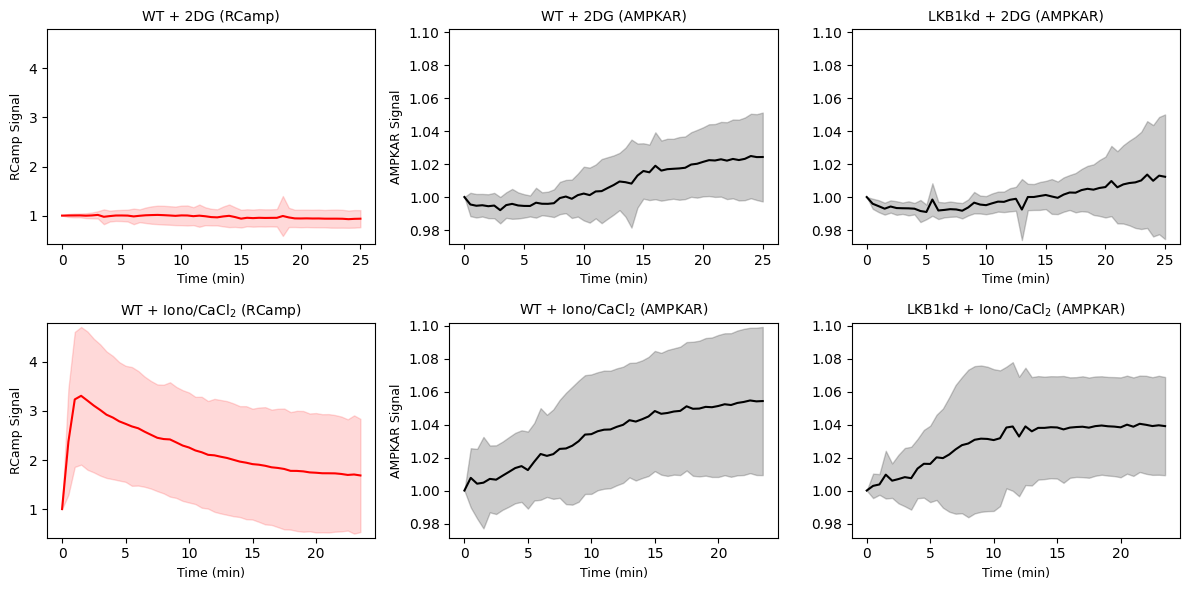

In [3]:
# ==========================================
# Plot raw HeLaAMPKAR3 data
# ==========================================
fig, axes = plt.subplots(2, 3, figsize=(12, 6))

# --- 2DG treatment (top row) ---
# WT RCamp
ax = axes[0, 0]
ax.plot(rcamp_2dg_calcium_df['Time (min)'], rcamp_2dg_calcium_df['MEAN'], color='red', label='RCamp')
ax.fill_between(rcamp_2dg_calcium_df['Time (min)'], rcamp_2dg_calcium_df['MEAN'] - rcamp_2dg_calcium_df['STD'],
                rcamp_2dg_calcium_df['MEAN'] + rcamp_2dg_calcium_df['STD'], alpha=0.15, color='red')
ax.set_title('WT + 2DG (RCamp)', fontsize=10)
ax.set_ylabel('RCamp Signal', fontsize=9)

# WT AMPKAR
ax = axes[0, 1]
ax.plot(rcamp_2dg_df['Time (min)'], rcamp_2dg_df['MEAN'], color='k', label='AMPKAR')
ax.fill_between(rcamp_2dg_df['Time (min)'], rcamp_2dg_df['MEAN'] - rcamp_2dg_df['STD'],
                rcamp_2dg_df['MEAN'] + rcamp_2dg_df['STD'], alpha=0.2, color='k')
ax.set_title('WT + 2DG (AMPKAR)', fontsize=10)
ax.set_ylabel('AMPKAR Signal', fontsize=9)

# LKB1kd AMPKAR
ax = axes[0, 2]
ax.plot(lkb1kd_2dg_df['Time (min)'], lkb1kd_2dg_df['MEAN'], color='k', label='AMPKAR')
ax.fill_between(lkb1kd_2dg_df['Time (min)'], lkb1kd_2dg_df['MEAN'] - lkb1kd_2dg_df['STD'],
                lkb1kd_2dg_df['MEAN'] + lkb1kd_2dg_df['STD'], alpha=0.2, color='k')
ax.set_title('LKB1kd + 2DG (AMPKAR)', fontsize=10)

# --- Iono treatment (bottom row) ---
# WT RCamp
ax = axes[1, 0]
ax.plot(rcamp_iono_calcium_df['Time (min)'], rcamp_iono_calcium_df['MEAN'], color='red', label='RCamp')
ax.fill_between(rcamp_iono_calcium_df['Time (min)'], rcamp_iono_calcium_df['MEAN'] - rcamp_iono_calcium_df['STD'],
                rcamp_iono_calcium_df['MEAN'] + rcamp_iono_calcium_df['STD'], alpha=0.15, color='red')
ax.set_title('WT + Iono/CaCl$_2$ (RCamp)', fontsize=10)
ax.set_ylabel('RCamp Signal', fontsize=9)

# WT AMPKAR
ax = axes[1, 1]
ax.plot(rcamp_iono_df['Time (min)'], rcamp_iono_df['MEAN'], color='k', label='AMPKAR')
ax.fill_between(rcamp_iono_df['Time (min)'], rcamp_iono_df['MEAN'] - rcamp_iono_df['STD'],
                rcamp_iono_df['MEAN'] + rcamp_iono_df['STD'], alpha=0.2, color='k')
ax.set_title('WT + Iono/CaCl$_2$ (AMPKAR)', fontsize=10)
ax.set_ylabel('AMPKAR Signal', fontsize=9)

# LKB1kd AMPKAR
ax = axes[1, 2]
ax.plot(lkb1kd_iono_df['Time (min)'], lkb1kd_iono_df['MEAN'], color='k', label='AMPKAR')
ax.fill_between(lkb1kd_iono_df['Time (min)'], lkb1kd_iono_df['MEAN'] - lkb1kd_iono_df['STD'],
                lkb1kd_iono_df['MEAN'] + lkb1kd_iono_df['STD'], alpha=0.2, color='k')
ax.set_title('LKB1kd + Iono/CaCl$_2$ (AMPKAR)', fontsize=10)

for ax in axes.flat:
    ax.set_xlabel('Time (min)', fontsize=9)

# Shared ylim for all AMPKAR subplots (columns 1 and 2)
ampkar_dfs = [rcamp_2dg_df, lkb1kd_2dg_df, rcamp_iono_df, lkb1kd_iono_df]
ampkar_ymin = min((df['MEAN'] - df['STD']).min() for df in ampkar_dfs)
ampkar_ymax = max((df['MEAN'] + df['STD']).max() for df in ampkar_dfs)
ampkar_margin = 0.02 * (ampkar_ymax - ampkar_ymin)
for r in range(2):
    for c in [1, 2]:
        axes[r, c].set_ylim(ampkar_ymin - ampkar_margin, ampkar_ymax + ampkar_margin)

# Shared ylim for RCamp subplots (column 0)
rcamp_dfs = [rcamp_2dg_calcium_df, rcamp_iono_calcium_df]
rcamp_ymin = min((df['MEAN'] - df['STD']).min() for df in rcamp_dfs)
rcamp_ymax = max((df['MEAN'] + df['STD']).max() for df in rcamp_dfs)
rcamp_margin = 0.02 * (rcamp_ymax - rcamp_ymin)
for r in range(2):
    axes[r, 0].set_ylim(rcamp_ymin - rcamp_margin, rcamp_ymax + rcamp_margin)

fig.tight_layout()
fig.savefig(f'../../../AMPKARkey_data/raw_plot.pdf')

In [4]:
# Save AMPKAR data as .npz files

savedir = '../../../AMPKARkey_data/'

hela_ampkar_experiments = {
    'RCamp_2DG': (rcamp_2dg_df, norm_rcamp_2dg, norm_rcamp_2dg_sd),
    'LKB1kd_2DG': (lkb1kd_2dg_df, norm_lkb1kd_2dg, norm_lkb1kd_2dg_sd),
    'RCamp_Iono': (rcamp_iono_df, norm_rcamp_iono, norm_rcamp_iono_sd),
    'LKB1kd_Iono': (lkb1kd_iono_df, norm_lkb1kd_iono, norm_lkb1kd_iono_sd),
}

for name, (df, nm, ns) in hela_ampkar_experiments.items():
    fname = savedir + 'HeLaAMPKAR3_' + name + '.npz'
    np.savez(fname,
             times=df['Time (min)'].to_numpy(),
             mean=nm.to_numpy(),
             std=ns.to_numpy(),
             std_constant=ns.mean())
    print(f'Saved {fname}')

Saved ../../../AMPKARkey_data/HeLaAMPKAR3_RCamp_2DG.npz
Saved ../../../AMPKARkey_data/HeLaAMPKAR3_LKB1kd_2DG.npz
Saved ../../../AMPKARkey_data/HeLaAMPKAR3_RCamp_Iono.npz
Saved ../../../AMPKARkey_data/HeLaAMPKAR3_LKB1kd_Iono.npz


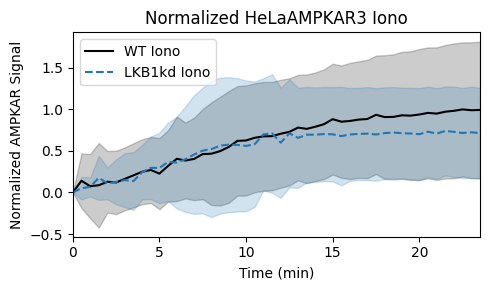

In [5]:
# Plot normalized HeLaAMPKAR3 LKB1kd Iono data (with WT Iono reference)
fig, ax = plt.subplots(figsize=(5, 3))

# WT Iono
ax.plot(rcamp_iono_df['Time (min)'], norm_rcamp_iono, color='k', label='WT Iono')
ax.fill_between(rcamp_iono_df['Time (min)'],
                norm_rcamp_iono - norm_rcamp_iono_sd,
                norm_rcamp_iono + norm_rcamp_iono_sd,
                alpha=0.2, color='k')

# LKB1kd Iono
ax.plot(lkb1kd_iono_df['Time (min)'], norm_lkb1kd_iono, color='tab:blue', linestyle='--', label='LKB1kd Iono')
ax.fill_between(lkb1kd_iono_df['Time (min)'],
                norm_lkb1kd_iono - norm_lkb1kd_iono_sd,
                norm_lkb1kd_iono + norm_lkb1kd_iono_sd,
                alpha=0.2, color='tab:blue')

ax.set_xlabel('Time (min)')
ax.set_ylabel('Normalized AMPKAR Signal')
ax.set_title('Normalized HeLaAMPKAR3 Iono')
ax.legend()
ax.set_xlim([0, lkb1kd_iono_df['Time (min)'].max()])
fig.tight_layout()